In [6]:
#TASK 1
# loading dataset
import pandas as pd
data=pd.read_csv("/content/StudentsPerformance.csv")

#printing the columns info

print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None


In [21]:
print(data.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [22]:
print(data.describe)

<bound method NDFrame.describe of      gender race/ethnicity parental level of education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
..      ...            ...                         ...           ...   
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test preparation course  math score  reading score  writing score  
0                      none  

In [23]:
# handle the missing values
print(data.isnull().sum())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [7]:
#label encoding
from sklearn.preprocessing import LabelEncoder, StandardScaler
le = LabelEncoder()
for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

In [8]:
#standardScaler
scaler = StandardScaler()
data[['math score', 'reading score', 'writing score']] = scaler.fit_transform(
    data[['math score', 'reading score', 'writing score']]
)

In [9]:
from sklearn.model_selection import train_test_split
X = data.drop('math score', axis=1)  # Features
y = data['math score']               # Target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [10]:
data.to_csv("processed_students.csv", index=False)


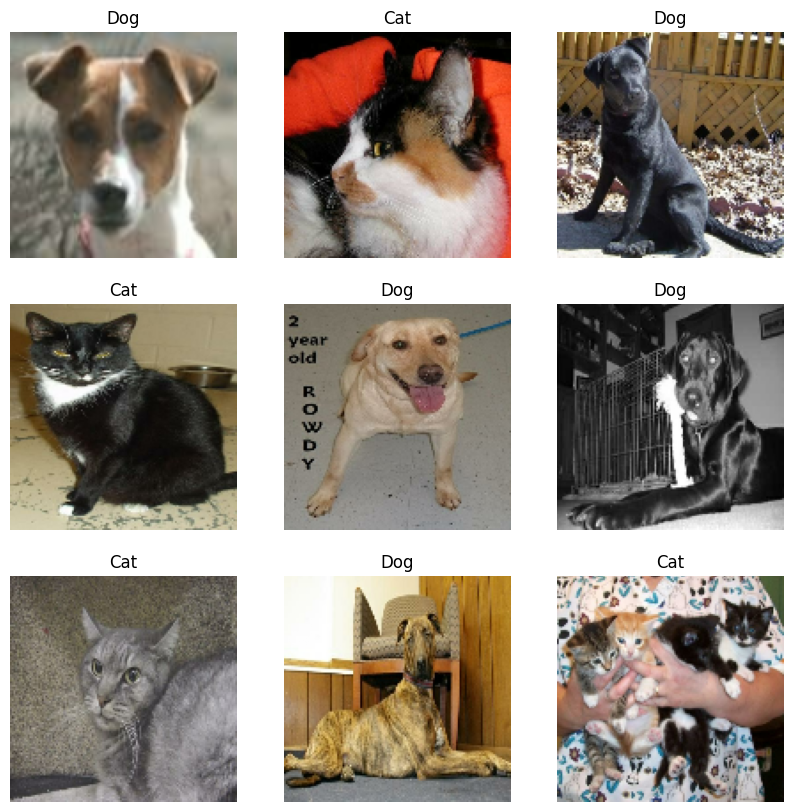

Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.6201 - loss: 0.6614 - val_accuracy: 0.7481 - val_loss: 0.5192
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 27s 47ms/step - accuracy: 0.7716 - loss: 0.4797 - val_accuracy: 0.7711 - val_loss: 0.4793
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 28s 49ms/step - accuracy: 0.8350 - loss: 0.3602 - val_accuracy: 0.7702 - val_loss: 0.5408
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.9109 - loss: 0.2189 - val_accuracy: 0.7502 - val_loss: 0.6630
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.9582 - loss: 0.1148 - val_accuracy: 0.7358 - val_loss: 0.9350
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.7328 - loss: 0.9966
Test Accuracy: 0.74


In [4]:
# TASK 2
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

#load data
(train_ds, test_ds), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

def preprocess(image, label):
    image = tf.image.resize(image, (128, 128))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Preprocessing
train_ds = train_ds.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)

#  Display Sample Images
class_names = ['Cat', 'Dog']
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        label = class_names[labels[i].numpy()]
        plt.title(label)
        plt.axis("off")
plt.show()

#  Build the Model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Binary classification
])

#  Compile
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train
model.fit(train_ds, epochs=5, validation_data=test_ds)

# Evaluate
loss, acc = model.evaluate(test_ds)
print(f"Test Accuracy: {acc:.2f}")


In [2]:
# TASK 4
!pip install pulp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 26.7 MB/s eta 0:00:00


In [3]:
from pulp import LpMaximize, LpProblem, LpVariable

problem = LpProblem("Maximize_Profit", LpMaximize)

x_A = LpVariable('x_A', lowBound=0, cat='Continuous')  # Product A
x_B = LpVariable('x_B', lowBound=0, cat='Continuous')  # Product B

problem += 40 * x_A + 50 * x_B, "Total Profit"

problem += 4 * x_A + 5 * x_B <= 100, "Labor Constraint"
problem += 3 * x_A + 4 * x_B <= 80, "Material Constraint"


problem.solve()

print(f"Status: {problem.status}")
print(f"Number of Product A to produce: {x_A.varValue:.2f}")
print(f"Number of Product B to produce: {x_B.varValue:.2f}")
print(f"Maximum Profit: ${problem.objective.value():.2f}")


Status: 1
Number of Product A to produce: 0.00
Number of Product B to produce: 20.00
Maximum Profit: $1000.00
